# Machine learning Pipeline using the CIFAR-2 dataset


In this section, you will implement a complete machine learning pipeline, experiment with extending
the model architecture and evaluate and analyze the results of your training process. This pipeline
should include a - data loading, data analysis and preprocessing, b - definition of a neural network,
c - implementation of the training process, d - experimentation with different model architectures,
e - hyperparameter tuning and model selection, f - model evaluation.

In [263]:
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
import torch.nn as nn

In [264]:
def set_torch_seed(seed=42):
    """Set seed for reproducibility."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [265]:
def load_cifar2(train_val_split=0.9, data_path='../data/', batch_size=64, seed=seed, shuffle_train=True):
    #we do the same as in the gradient descent assignement
    
    cifar10_mean = (0.4914, 0.4822, 0.4465)
    cifar10_std = (0.2470, 0.2435, 0.2616)
    preprocessor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
    ])
    train = datasets.CIFAR10(data_path, train=True, download=True, transform=preprocessor)
    test = datasets.CIFAR10(data_path, train=False, download=True, transform=preprocessor)

    keep = {0: 0, 2: 1} # keep only airplane and bird, and rename them to 0 and 1
    
    def filter_dataset(ds):
        targets = np.array(ds.targets)
        mask = np.isin(targets, [0, 2])
        ds.data = ds.data[mask] #this filteres the images
        ds.targets = [keep[int(t)] for t in targets[mask]] #this filters the labels
    
    filter_dataset(train)
    filter_dataset(test)

    #now we split the training set into train and validation
    n_total = len(train)
    n_train = int(train_val_split * n_total)
    n_val = n_total - n_train

    g = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(train, [n_train, n_val], generator=g)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle_train)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

    return train_ds, val_ds, test, train_loader, val_loader, test_loader



Let's analyse the dataset:

In [266]:
def analyse_cifar2(train_ds, val_ds, test_ds):
    
    def get_targets(ds):
        if hasattr(ds, "indices"):
            base_targets = np.array(ds.dataset.targets)
            return base_targets[ds.indices]
        return np.array(ds.targets)
    
    def stats(name, ds):
        targets = get_targets(ds)
        unique, counts = np.unique(targets, return_counts=True)
        print(f'{name}: size={len(ds)}, class distribution={dict(zip(unique, counts))}')
    
    #Dataset sizes and label distributions
    stats('Train', train_ds)
    stats('Validation', val_ds)
    stats('Test', test_ds)

    #check for a single sample to see the shape
    x, y = train_ds[0]
    print(f'Sample shape: {x.shape}, label: {y}')
    print('Pixel value range:', x.min().item(), 'to', x.max().item())
    
    #batch size and shape
    loader = DataLoader(train_ds, batch_size=64, shuffle=False)
    x_batch, y_batch = next(iter(loader))

    print(f'Batch shape: {x_batch.shape}, labels shape: {y_batch.shape}')
    print(f" Channel means: {x_batch.mean(dim=[0, 2, 3])}, stds: {x_batch.std(dim=[0, 2, 3])}")

train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = load_cifar2()

analyse_cifar2(train_ds, val_ds, test_ds)


Files already downloaded and verified
Files already downloaded and verified
Train: size=9000, class distribution={0: 4531, 1: 4469}
Validation: size=1000, class distribution={0: 469, 1: 531}
Test: size=2000, class distribution={0: 1000, 1: 1000}
Sample shape: torch.Size([3, 32, 32]), label: 0
Pixel value range: -1.9894737005233765 to 2.12648868560791
Batch shape: torch.Size([64, 3, 32, 32]), labels shape: torch.Size([64])
 Channel means: tensor([0.0900, 0.1890, 0.1946]), stds: tensor([0.9477, 0.9408, 0.9889])


In [267]:
def train(n_epochs, optimizer, model, loss_fn, train_loader, val_loader, seed=42):
    
    device = next(model.parameters()).device
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0

        for images, labels in train_loader:
            #move the data to the same device as the model
            images, labels = images.to(device=device, dtype=torch.double), labels.to(device=device, dtype=torch.long)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * images.size(0)

        epoch_loss /= len(train_loader.dataset)
        train_losses.append(epoch_loss)
        
        val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc) 
        print(f'Epoch {epoch+1}/{n_epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    return train_losses, val_losses, val_accuracies

def evaluate(model, data_loader, loss_fn, device, val_loader=None):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, dtype=torch.double)
            labels = labels.to(device, dtype=torch.long)
            
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


In [268]:
class MyMLP(nn.Module):
    def __init__(self, layer_sizes, dropout_rate=0.5, seed=42):
        super(MyMLP, self).__init__()
        layers = []
        for i in range(len(layer_sizes) - 1):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            
            if i < len(layer_sizes) - 2: # no activation after last layer
                layers.append(nn.ReLU())
                if dropout_rate > 0:
                    layers.append(nn.Dropout(dropout_rate))
        self.model = nn.Sequential(*layers)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.flatten(x)
        x= self.model(x)
        return x

In [269]:
def run_experiment(layer_sizes, train_loader, val_loader, test_loader,
                   lr=0.1, momentum=0.0, weight_decay=0.0, dropout_rate=0.0,
                   n_epochs=20, seed=42, device=None):
    
    set_torch_seed(seed)

    model = MyMLP(layer_sizes, dropout_rate).double()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    train_losses, val_losses, val_accuracies = train(n_epochs, optimizer, model, loss_fn, train_loader, val_loader)
    final_val_loss, final_val_acc = evaluate(model, val_loader, loss_fn, device)

    results = {
        "architecture": arch_name,
        "layers": layer_sizes,
        "dropout": dropout_rate,
        "learning_rate": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
        "best_val_accuracy": max(val_accuracies),
        "final_val_loss": final_val_loss,
        "final_val_accuracy": final_val_acc
    }

    return results

In [270]:
architectures = {
    "A_baseline": [3072, 128, 2],
    "B_deep": [3072, 256, 128, 2],
    "C_wide": [3072, 512, 2],
    "D_deeper": [3072, 256, 128, 64, 2],
}


param_grid = [
    {"lr": 0.1,  "momentum": 0.0, "weight_decay": 0.0,  "dropout_rate": 0.0, "n_epochs": 10},
    {"lr": 0.1,  "momentum": 0.0, "weight_decay": 0.1,  "dropout_rate": 0.0, "n_epochs": 10},
    {"lr": 0.1,  "momentum": 0.0, "weight_decay": 0.1,  "dropout_rate": 0.5, "n_epochs": 10},
    {"lr": 0.1,  "momentum": 0.0, "weight_decay": 0.0,  "dropout_rate": 0.2, "n_epochs": 10},
    {"lr": 0.01, "momentum": 0.0, "weight_decay": 0.0, "dropout_rate": 0.0, "n_epochs": 10},
    {"lr": 0.01, "momentum": 0.9, "weight_decay": 0.0,  "dropout_rate": 0.0, "n_epochs": 10},
    {"lr": 0.01, "momentum": 0.9, "weight_decay": 0.0,  "dropout_rate": 0.5, "n_epochs": 10},
    {"lr": 0.01, "momentum": 0.9, "weight_decay": 0.1,  "dropout_rate": 0.0, "n_epochs": 10},
    {"lr": 0.01,  "momentum": 0.0, "weight_decay": 0.0,  "dropout_rate": 0.2, "n_epochs": 10},
    {"lr": 0.001, "momentum": 0.0, "weight_decay": 0.0, "dropout_rate": 0.0, "n_epochs": 10},
    {"lr": 0.001, "momentum": 0.9, "weight_decay": 0.0, "dropout_rate": 0.0, "n_epochs": 10},
    {"lr": 0.001, "momentum": 0.0, "weight_decay": 0.1, "dropout_rate": 0.0, "n_epochs": 10},
    {"lr": 0.001, "momentum": 0.0, "weight_decay": 0.0, "dropout_rate": 0.5, "n_epochs": 10},
    {"lr": 0.001,  "momentum": 0.0, "weight_decay": 0.0,  "dropout_rate": 0.2, "n_epochs": 10},

]


Running the experiments all together for 4 x 4 combinations

In [271]:
# Run all experiments
all_results = []
total_experiments = len(architectures) * len(param_grid)
current = 0
set_torch_seed(seed)

print(f"Running {total_experiments} experiments...\n")

for arch_name, layer_sizes in architectures.items():
    for params in param_grid:
        current += 1
        print(f"[{current}/{total_experiments}] Testing {arch_name} with lr={params['lr']}, "
              f"momentum={params['momentum']}, weight_decay={params['weight_decay']}, dropout={params['dropout_rate']}")
        
        results = run_experiment(layer_sizes, train_loader, val_loader, test_loader, **params)
        results["architecture"] = arch_name
        all_results.append(results)
        
        print(f"  → Validation Accuracy: {results['final_val_accuracy']:.2f}%\n")

print("All experiments completed!")

Running 56 experiments...

[1/56] Testing A_baseline with lr=0.1, momentum=0.0, weight_decay=0.0, dropout=0.0
Epoch 1/10, Train Loss: 0.5036, Val Loss: 0.4774, Val Acc: 82.10%
Epoch 2/10, Train Loss: 0.4641, Val Loss: 0.4718, Val Acc: 79.80%
Epoch 3/10, Train Loss: 0.4272, Val Loss: 0.4051, Val Acc: 82.50%
Epoch 4/10, Train Loss: 0.4130, Val Loss: 0.3982, Val Acc: 84.50%
Epoch 5/10, Train Loss: 0.3860, Val Loss: 0.5525, Val Acc: 75.30%
Epoch 6/10, Train Loss: 0.3781, Val Loss: 0.4014, Val Acc: 85.40%
Epoch 7/10, Train Loss: 0.3656, Val Loss: 0.4257, Val Acc: 82.00%
Epoch 8/10, Train Loss: 0.3510, Val Loss: 0.4471, Val Acc: 84.80%
Epoch 9/10, Train Loss: 0.3359, Val Loss: 0.3982, Val Acc: 84.90%
Epoch 10/10, Train Loss: 0.3204, Val Loss: 0.4046, Val Acc: 84.90%
  → Validation Accuracy: 84.90%

[2/56] Testing A_baseline with lr=0.1, momentum=0.0, weight_decay=0.1, dropout=0.0
Epoch 1/10, Train Loss: 0.5155, Val Loss: 0.4969, Val Acc: 80.40%
Epoch 2/10, Train Loss: 0.5011, Val Loss: 0.481

Let's visualize!

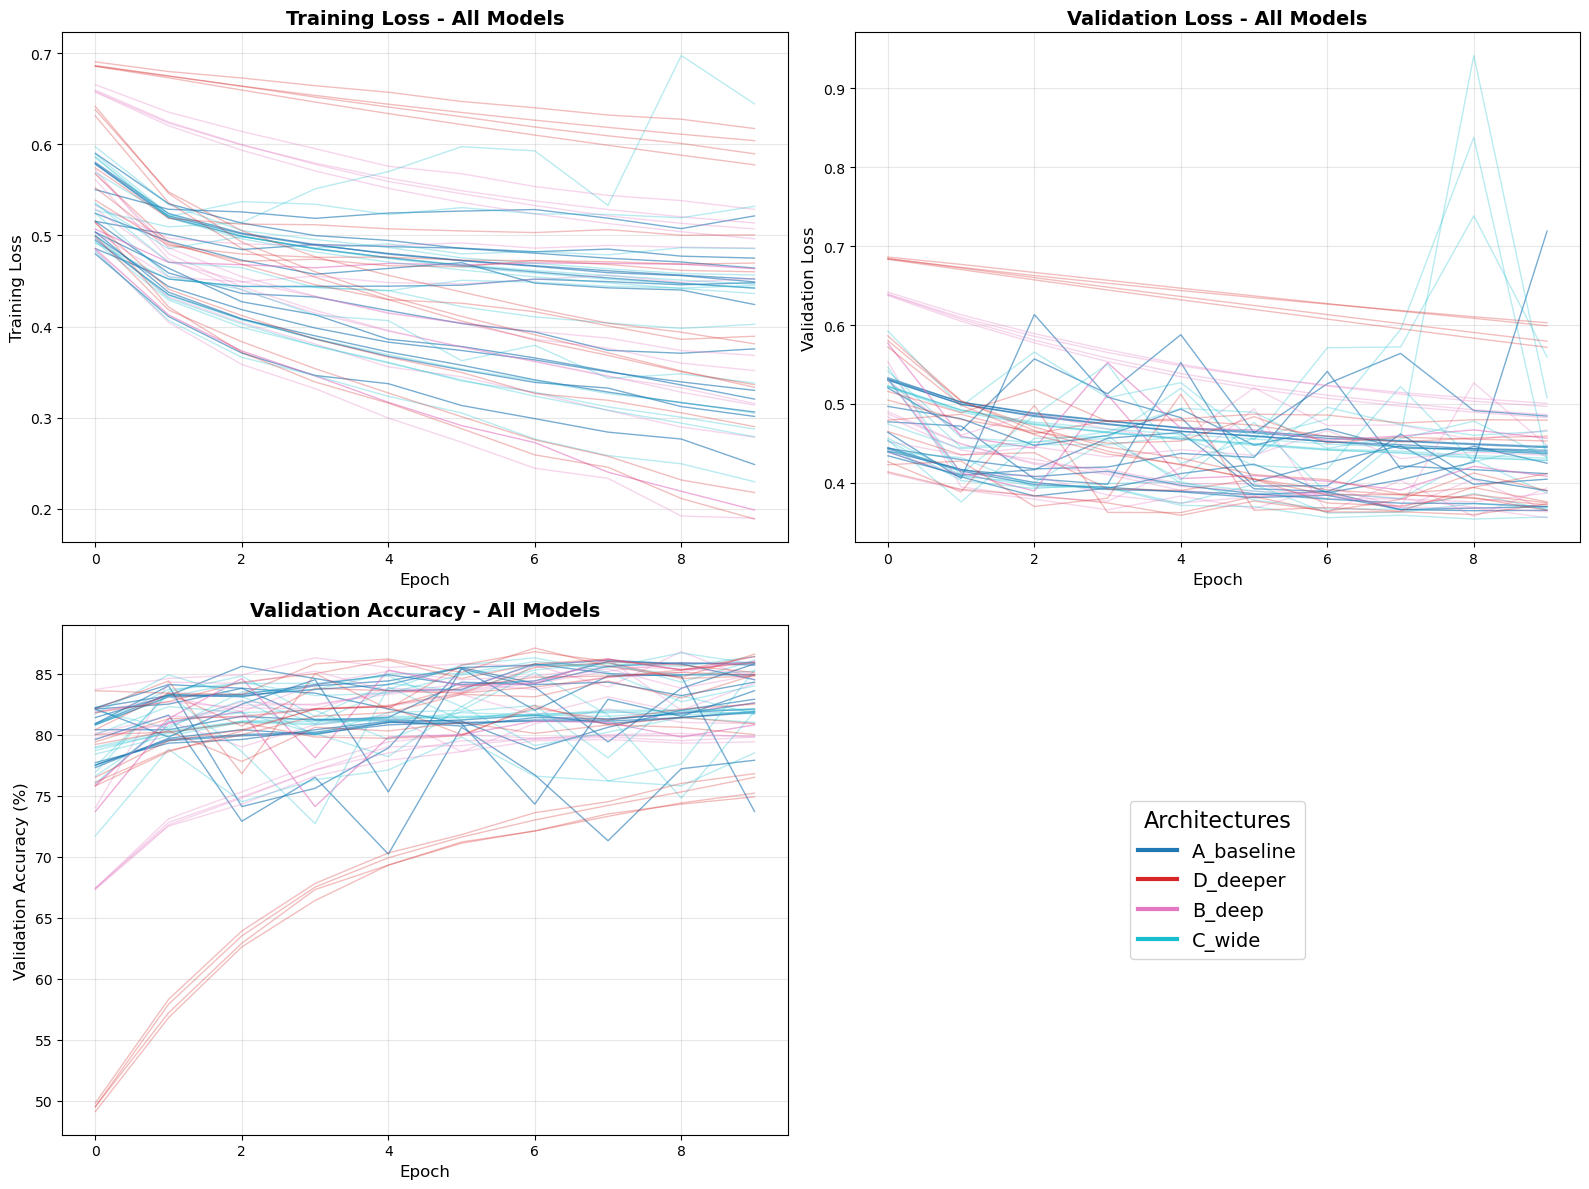

In [272]:
import matplotlib.pyplot as plt
import numpy as np

#plot training and validation curves for all models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#group by architecture
architectures_list = list(set([r['architecture'] for r in all_results]))
colors = plt.cm.tab10(np.linspace(0, 1, len(architectures_list)))
arch_colors = dict(zip(architectures_list, colors))

#training Loss for all models
ax = axes[0, 0]
for i, r in enumerate(all_results):
    alpha = 0.3 if i > 15 else 0.6  # Make it less crowded
    ax.plot(r['train_losses'], alpha=alpha, color=arch_colors[r['architecture']], linewidth=1)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Training Loss - All Models', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

#validation Loss for all models
ax = axes[0, 1]
for i, r in enumerate(all_results):
    alpha = 0.3 if i > 15 else 0.6
    ax.plot(r['val_losses'], alpha=alpha, color=arch_colors[r['architecture']], linewidth=1)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Loss', fontsize=12)
ax.set_title('Validation Loss - All Models', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

#validation Accuracy for all models
ax = axes[1, 0]
for i, r in enumerate(all_results):
    alpha = 0.3 if i > 15 else 0.6
    ax.plot(r['val_accuracies'], alpha=alpha, color=arch_colors[r['architecture']], linewidth=1)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('Validation Accuracy - All Models', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# legend showing architectures
ax = axes[1, 1]
ax.axis('off')
for arch, color in arch_colors.items():
    ax.plot([], [], color=color, linewidth=3, label=arch)
ax.legend(loc='center', fontsize=14, title='Architectures', title_fontsize=16)

plt.tight_layout()

plt.show()


In [273]:
import pandas as pd

#creating a clean dataframe
comparison_df = pd.DataFrame([{
    'Architecture': res['architecture'],
    'LR': res['learning_rate'],
    'Momentum': res['momentum'],
    'Weight Decay': res['weight_decay'],
    'Dropout': res['dropout'],
    'Val Acc': f"{res['final_val_accuracy']:.2f}%",
    'Val Loss': f"{res['final_val_loss']:.4f}",
} for res in all_results])

#sorting by validation accuracy
comparison_df['Val Acc Num'] = comparison_df['Val Acc'].str.rstrip('%').astype(float)
comparison_df_sorted = comparison_df.sort_values('Val Acc Num', ascending=False).drop('Val Acc Num', axis=1)

print("\nTop 10 Models:\n")
print(comparison_df_sorted.head(10).to_string(index=False))

#best model
best = max(all_results, key=lambda x: x['final_val_accuracy'])
print(f"\n\nBest Model:")
print(f"  {best['architecture']}: {best['layers']}")
print(f"  LR={best['learning_rate']}, Momentum={best['momentum']}, Weigth_decay={best['weight_decay']}, Dropout={best['dropout']}")
print(f"  Validation Accuracy: {best['final_val_accuracy']:.2f}%\n")



Top 10 Models:

Architecture    LR  Momentum  Weight Decay  Dropout Val Acc Val Loss
    D_deeper 0.010       0.9           0.0      0.0  86.60%   0.3902
    D_deeper 0.001       0.9           0.0      0.0  86.40%   0.3651
      B_deep 0.001       0.9           0.0      0.0  86.40%   0.3557
      C_wide 0.010       0.0           0.0      0.2  86.40%   0.3678
      C_wide 0.100       0.0           0.0      0.0  86.10%   0.3869
      B_deep 0.100       0.0           0.0      0.0  86.00%   0.4083
    D_deeper 0.100       0.0           0.0      0.2  85.90%   0.3734
  A_baseline 0.010       0.0           0.0      0.2  85.90%   0.3700
      C_wide 0.001       0.9           0.0      0.0  85.80%   0.3567
      B_deep 0.010       0.0           0.0      0.2  85.80%   0.3633


Best Model:
  D_deeper: [3072, 256, 128, 64, 2]
  LR=0.01, Momentum=0.9, Weigth_decay=0.0, Dropout=0.0
  Validation Accuracy: 86.60%



In [274]:
set_torch_seed(seed)
best_model = max(all_results, key=lambda x: x['final_val_accuracy'])

print(f"Best Model: {best_model['architecture']} with layers {best_model['layers']}")
print(f"  LR={best_model['learning_rate']}, Momentum={best_model['momentum']}, Weigth_decay={best_model['weight_decay']}, Dropout={best_model['dropout']}")

#retraining best model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = seed
best_model = MyMLP(best_model['layers'], best_model['dropout']).double().to(device)
optimizer = torch.optim.SGD(best_model.parameters(), lr=best['learning_rate'], momentum=best['momentum'], weight_decay=best['weight_decay'])
loss_fn = nn.CrossEntropyLoss()

n_epochs = 10
print("\nRetraining best model on combined train+val set...")
train(n_epochs, optimizer, best_model, loss_fn, DataLoader(train_ds + val_ds, batch_size=64, shuffle=True), val_loader)
#test
final_test_loss, final_test_acc = evaluate(best_model, test_loader, loss_fn, device)
print(f"Final Test Accuracy: {final_test_acc:.2f}%, Test Loss: {final_test_loss:.4f}")

Best Model: D_deeper with layers [3072, 256, 128, 64, 2]
  LR=0.01, Momentum=0.9, Weigth_decay=0.0, Dropout=0.0

Retraining best model on combined train+val set...
Epoch 1/10, Train Loss: 0.5053, Val Loss: 0.3943, Val Acc: 83.50%
Epoch 2/10, Train Loss: 0.4056, Val Loss: 0.3485, Val Acc: 85.60%
Epoch 3/10, Train Loss: 0.3653, Val Loss: 0.3038, Val Acc: 88.80%
Epoch 4/10, Train Loss: 0.3330, Val Loss: 0.2977, Val Acc: 89.20%
Epoch 5/10, Train Loss: 0.3069, Val Loss: 0.2437, Val Acc: 90.60%
Epoch 6/10, Train Loss: 0.2834, Val Loss: 0.2095, Val Acc: 92.30%
Epoch 7/10, Train Loss: 0.2606, Val Loss: 0.2307, Val Acc: 90.60%
Epoch 8/10, Train Loss: 0.2258, Val Loss: 0.1580, Val Acc: 95.70%
Epoch 9/10, Train Loss: 0.2194, Val Loss: 0.1670, Val Acc: 93.50%
Epoch 10/10, Train Loss: 0.1919, Val Loss: 0.1654, Val Acc: 94.50%
Final Test Accuracy: 83.80%, Test Loss: 0.4006


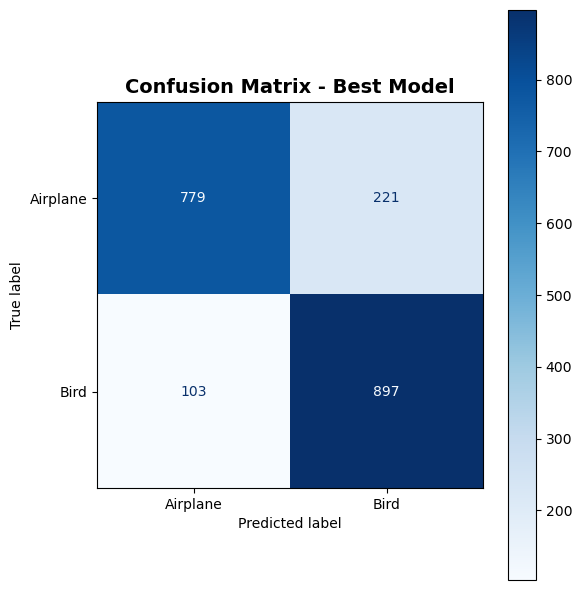

In [277]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
best_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, dtype=torch.double)
        labels = labels.to(device, dtype=torch.long)
        
        outputs = best_model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

#creating the matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Airplane', 'Bird'])
disp.plot(cmap=plt.cm.Blues, ax=ax)


#plotting
plt.title('Confusion Matrix - Best Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
